# 1. Setup

In [1]:
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

### Convert CSV products to DataFrame

In [2]:
df_search   = pd.read_csv('../data/processed/products_search.csv')
df_enriched = pd.read_csv('../data/processed/products_enriched.csv')

print(df_search.shape)
print(df_enriched.shape)    

(1386, 12)
(32, 8)


# 2. Data Cleaning

### Clean and format category name

In [3]:
df_search['category'] = df_search['category'].apply(lambda x: x.replace('_', ' ').title())
df_search.head()

,asin,title,rating,review_count,sponsored,is_prime,search_position,recent_sales,price_primary,price_rrp,category,page
0,B09NXS395V,24K Gold Under Eye Patches - 60 Pack for Puffy...,4.1,14615.0,False,False,1,10K+ bought in past month,9.39,9.99,Beauty Personal Care,1
1,B091NJQ29P,Good Molecules Yerba Mate Wake Up Eye Gel - Hy...,4.2,28653.0,False,False,2,60K+ bought in past month,5.97,NaN,Beauty Personal Care,1
2,B08Z5X1L1S,Gifts for Women Gift Basket for Women - 10 Pc ...,4.6,2369.0,False,False,3,5K+ bought in past month,34.98,65.00,Beauty Personal Care,1
3,B08KT2Z93D,"eos Shea Better Body Lotion Vanilla Cashmere, ...",4.7,65741.0,False,False,4,100K+ bought in past month,9.97,10.99,Beauty Personal Care,1
4,B0CMV2DCXT,CHMI Under Eye Patches (50 Pairs) - 24K Gold E...,4.5,1021.0,False,False,5,5K+ bought in past month,9.99,NaN,Beauty Personal Care,1


### Function to parse recent sales to a number

In [4]:
def parse_recent_sales(value):
    # get the integer value from recent sales
    if not isinstance(value, str):
        return None
    
    value = value.upper()

    if 'K+' in value:
        return int(float(value.split('K+')[0].strip()) *1000)
    elif '+' in value:
        return int(value.split('+')[0].strip())
    else:
        return None
        

### Applied function to cleanup

In [5]:
df_search['recent_sales_approx'] = df_search['recent_sales'].apply(parse_recent_sales)
df_search.head()

,asin,title,rating,review_count,sponsored,is_prime,search_position,recent_sales,price_primary,price_rrp,category,page,recent_sales_approx
0,B09NXS395V,24K Gold Under Eye Patches - 60 Pack for Puffy...,4.1,14615.0,False,False,1,10K+ bought in past month,9.39,9.99,Beauty Personal Care,1,10000.0
1,B091NJQ29P,Good Molecules Yerba Mate Wake Up Eye Gel - Hy...,4.2,28653.0,False,False,2,60K+ bought in past month,5.97,NaN,Beauty Personal Care,1,60000.0
2,B08Z5X1L1S,Gifts for Women Gift Basket for Women - 10 Pc ...,4.6,2369.0,False,False,3,5K+ bought in past month,34.98,65.00,Beauty Personal Care,1,5000.0
3,B08KT2Z93D,"eos Shea Better Body Lotion Vanilla Cashmere, ...",4.7,65741.0,False,False,4,100K+ bought in past month,9.97,10.99,Beauty Personal Care,1,100000.0
4,B0CMV2DCXT,CHMI Under Eye Patches (50 Pairs) - 24K Gold E...,4.5,1021.0,False,False,5,5K+ bought in past month,9.99,NaN,Beauty Personal Care,1,5000.0


### Convert to integers 

In [10]:
df_search['review_count'] = df_search['review_count'].astype('Int64') # nullable int
df_search['recent_sales_approx'] = df_search['recent_sales_approx'].astype('Int64')
df_search.head(10)

,asin,title,rating,review_count,sponsored,is_prime,search_position,recent_sales,price_primary,price_rrp,category,page,recent_sales_approx,discount_pct,has_discount
0,B09NXS395V,24K Gold Under Eye Patches - 60 Pack for Puffy...,4.1,14615,False,False,1,10K+ bought in past month,9.39,9.99,Beauty Personal Care,1,10000,NaN,True
1,B091NJQ29P,Good Molecules Yerba Mate Wake Up Eye Gel - Hy...,4.2,28653,False,False,2,60K+ bought in past month,5.97,NaN,Beauty Personal Care,1,60000,9.3,False
2,B08Z5X1L1S,Gifts for Women Gift Basket for Women - 10 Pc ...,4.6,2369,False,False,3,5K+ bought in past month,34.98,65.00,Beauty Personal Care,1,5000,16.8,True
3,B08KT2Z93D,"eos Shea Better Body Lotion Vanilla Cashmere, ...",4.7,65741,False,False,4,100K+ bought in past month,9.97,10.99,Beauty Personal Care,1,100000,13.3,True
4,B0CMV2DCXT,CHMI Under Eye Patches (50 Pairs) - 24K Gold E...,4.5,1021,False,False,5,5K+ bought in past month,9.99,NaN,Beauty Personal Care,1,5000,NaN,False
5,B0CTK5ZTNK,"Under Eye Patches, 40 Pairs Eye Mask for Dark ...",4.5,5192,False,False,6,10K+ bought in past month,9.99,12.99,Beauty Personal Care,1,10000,20.0,True
6,B0CNV5SG4S,"Sleeping lip mask, Nourish & Hydrate Lip Mask ...",4.6,969,False,False,7,300+ bought in past month,4.99,6.99,Beauty Personal Care,1,300,NaN,True
7,B0C7W6GW8P,"e.l.f. Squeeze Me Lip Balm, Moisturizing Lip B...",4.5,19260,False,False,8,10K+ bought in past month,5.00,NaN,Beauty Personal Care,1,10000,NaN,False
8,B0CPCYP629,eos 24H Moisture Travel Body Lotion- Vanilla C...,4.8,3099,False,False,9,20K+ bought in past month,3.99,NaN,Beauty Personal Care,1,20000,23.3,False
9,B0DMTDN158,The Ordinary Glycolic Acid 7% Exfoliating Tone...,4.7,44753,False,False,10,40K+ bought in past month,7.65,9.00,Beauty Personal Care,1,40000,NaN,True


#### Merge Inner both df by ASIN (after clean up)

In [7]:
df_top = df_search.merge(df_enriched, on='asin', how='inner')
print(df_top.shape)

(34, 20)


### ⚠️ Data Limitations
- `recent_sales_approx` is an estimate derived from Amazon's "X+ bought in past month" 
  string, which only provides a lower bound (e.g. "10K+" could mean 10K or 500K).
  Also has 448 null values (~32% of dataset). 
  Amazon does not consistently expose the "X+ bought in past month"   field across all listings. NaN values represent missing data, not zero sales.
  High-rated products with many reviews may still have no sales data available.
  
- `engagement_score` should be interpreted as a relative ranking metric, not an absolute value.


### New columns with the current data

In [8]:
# Discount percentage, how much off vs original price
df_top['discount_pct'] = ((df_top['price_rrp'] - df_top['price_primary']) / df_top['price_rrp'] * 100).round(1)
df_search['discount_pct'] = ((df_top['price_rrp'] - df_top['price_primary']) / df_top['price_rrp'] * 100).round(1)

# Engagement score, sales weighted by rating (higher = popular AND well rated)
df_top['engagement_score'] = (df_top['recent_sales_approx'] * df_top['rating']).round(0)

# Has discount flag
df_top['has_discount'] = df_top['price_rrp'].notna()
df_search['has_discount'] = df_search['price_rrp'].notna()

# Convert to int
df_top['bsr_main'] = df_top['bsr_main'].astype('Int64')
df_top['bsr_sub']  = df_top['bsr_sub'].astype('Int64')
df_top.head(5)

,asin,title,rating,review_count,sponsored,is_prime,search_position,recent_sales,price_primary,price_rrp,...,brand,subcategory,image,is_fba,bsr_main,bsr_sub,seller_name,discount_pct,engagement_score,has_discount
0,B091NJQ29P,Good Molecules Yerba Mate Wake Up Eye Gel - Hy...,4.2,28653,False,False,2,60K+ bought in past month,5.97,NaN,...,Good Molecules,Gels,https://m.media-amazon.com/images/I/71QsFtfDUC...,True,115,1,Good Molecules US,NaN,252000.0,False
1,B08KT2Z93D,"eos Shea Better Body Lotion Vanilla Cashmere, ...",4.7,65741,False,False,4,100K+ bought in past month,9.97,10.99,...,eos,Lotions,https://m.media-amazon.com/images/I/51lP01--ej...,True,2,1,NaN,9.3,470000.0,True
2,B0DPHQRLJC,"eos Cashmere Body Wash – Vanilla Cashmere, Moi...",4.8,14386,False,False,20,70K+ bought in past month,9.98,11.99,...,eos,Body Washes,https://m.media-amazon.com/images/I/51bThha-95...,True,12,1,NaN,16.8,336000.0,True
3,B0DBF65JYY,medicube PDRN Pink Peptide Serum with Salmon D...,4.6,10387,False,False,27,80K+ bought in past month,18.90,21.80,...,medicube,Serums,https://m.media-amazon.com/images/I/615DOoCI6x...,True,48,4,Medicube & Aprilskin,13.3,368000.0,True
4,B09541P9WH,Amazon Basics Double-Tipped Cotton Swabs for P...,4.7,71667,False,False,33,100K+ bought in past month,2.84,NaN,...,Amazon Basics,Cotton Swabs,https://m.media-amazon.com/images/I/612HeyYXOn...,NaN,41,2,NaN,NaN,470000.0,False


# 3. Data Overiew (saves)

### Save DataFrames in a CSV files

In [25]:
df_search.to_csv('../data/processed/products_search_clean.csv', index=False)
df_top.to_csv('../data/processed/products_top_clean.csv', index=False)

print(f"products_search_clean: {df_search.shape}")
print(f"products_top_clean:    {df_top.shape}")


products_search_clean: (1386, 15)
products_top_clean:    (34, 23)


In [11]:
df_search.head(5)
df_search.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   asin                 1386 non-null   object 
 1   title                1386 non-null   object 
 2   rating               1356 non-null   float64
 3   review_count         1356 non-null   Int64  
 4   sponsored            1386 non-null   bool   
 5   is_prime             1386 non-null   bool   
 6   search_position      1386 non-null   int64  
 7   recent_sales         938 non-null    object 
 8   price_primary        1349 non-null   float64
 9   price_rrp            574 non-null    float64
 10  category             1386 non-null   object 
 11  page                 1386 non-null   int64  
 12  recent_sales_approx  938 non-null    Int64  
 13  discount_pct         17 non-null     float64
 14  has_discount         34 non-null     object 
dtypes: Int64(2), bool(2), float64(4), int6

# 4. Category Analysis (Products Search)

### Import config for visualizations

In [12]:
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import ArrowStyle
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter
import os

os.makedirs('../visuals', exist_ok=True)

## 4.1 Sales

In [13]:
df_sales_review = (
    df_search.groupby('category')
    .agg(
        total_sales=('recent_sales_approx', 'sum'),
        total_reviews=('review_count', 'sum')
    )
    .reset_index()
    )

df_sales_review['sales_pct']   = (df_sales_review['total_sales'] / df_sales_review['total_sales'].sum() * 100).round(1)
df_sales_review['reviews_pct'] = (df_sales_review['total_reviews'] / df_sales_review['total_reviews'].sum() * 100).round(1)

df_melted = df_sales_review.melt(
    id_vars='category',
    value_vars=['sales_pct', 'reviews_pct'],
    var_name='metric',
    value_name='percentage'
)

df_melted


,category,metric,percentage
0,Beauty Personal Care,sales_pct,60.0
1,Electronics,sales_pct,13.3
2,Home Kitchen,sales_pct,24.6
3,Sports Outdoors,sales_pct,2.1
4,Beauty Personal Care,reviews_pct,33.0
5,Electronics,reviews_pct,28.7
6,Home Kitchen,reviews_pct,28.8
7,Sports Outdoors,reviews_pct,9.5


### 4.1a Sales Graphic

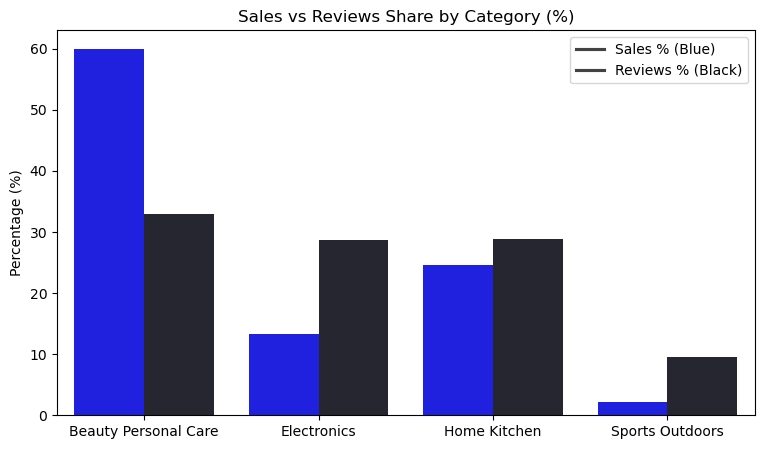

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df_melted, x='category', y='percentage', hue='metric', palette='dark:b_r', ax=ax)

ax.set_title('Sales vs Reviews Share by Category (%)')
ax.set_xlabel('')
ax.set_ylabel('Percentage (%)')
ax.legend(labels=['Sales % (Blue)', 'Reviews % (Black)'])
plt.savefig('../visuals/4.1a_sales_vs_reviews_percentage.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.1b Graphic Product Count per Sale

C:\Users\moco\AppData\Local\Temp\ipykernel_17736\3454092759.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_search, x='recent_sales_approx', palette='muted')
C:\Users\moco\AppData\Local\Temp\ipykernel_17736\3454092759.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([format_sales(int(t.get_text())) for t in ax.get_xticklabels()], rotation=45)


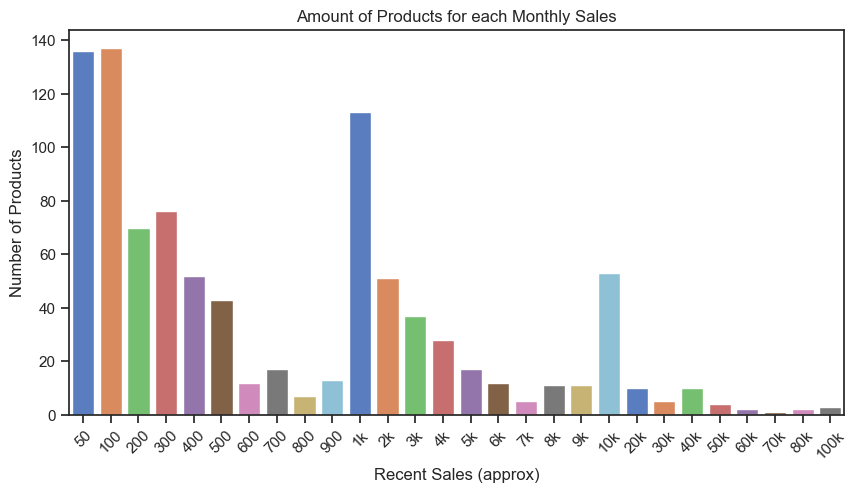

In [15]:
sns.set_theme(style='ticks')
plt.figure(figsize=(10, 5))
sns.countplot(data=df_search, x='recent_sales_approx', palette='muted')

def format_sales(val):
    val = int(val)
    return f'{val//1000}k' if val >= 1000 else str(val)

plt.title('Amount of Products for each Monthly Sales')
plt.xlabel('Recent Sales (approx)')
plt.ylabel('Number of Products')

ax = plt.gca()
ax.set_xticklabels([format_sales(int(t.get_text())) for t in ax.get_xticklabels()], rotation=45)

plt.xticks(rotation=45)
plt.savefig('../visuals/4.1.b_product_count_per_sale.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.2 Ratings

### 4.2a Average Rating and Reviews

In [16]:

df_rating_reviews = (
    df_search.groupby('category')
    .agg(
        avg_rating=('rating', 'mean'),
        avg_reviews=('review_count', 'mean')
    )
    .round(2)
    .reset_index()
)
df_rating_reviews

,category,avg_rating,avg_reviews
0,Beauty Personal Care,4.39,9307.54
1,Electronics,4.37,8929.43
2,Home Kitchen,4.43,7586.2
3,Sports Outdoors,4.36,2503.23


### 4.2a Graphic Avg Reviews & Rating

C:\Users\moco\AppData\Local\Temp\ipykernel_17736\3426760441.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_rating_reviews, x='avg_rating', y='category', palette='muted', ax=ax1)
C:\Users\moco\AppData\Local\Temp\ipykernel_17736\3426760441.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_rating_reviews, x='avg_reviews', y='category', palette='muted', ax=ax2)


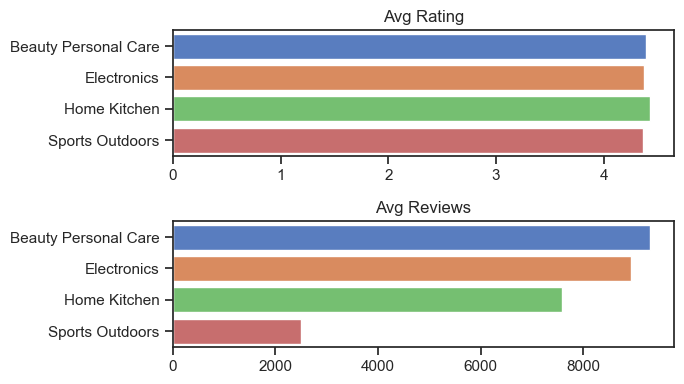

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 4))

sns.barplot(data=df_rating_reviews, x='avg_rating', y='category', palette='muted', ax=ax1)
sns.barplot(data=df_rating_reviews, x='avg_reviews', y='category', palette='muted', ax=ax2)

ax1.set_title('Avg Rating')
ax2.set_title('Avg Reviews')

ax1.set_xlabel('')
ax2.set_xlabel('')

ax1.set_ylabel('')
ax2.set_ylabel('')
plt.tight_layout()
plt.savefig('../visuals/4.2.a_avg_reviews_and_avg_rating.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2b Histogram - Rating Distribution

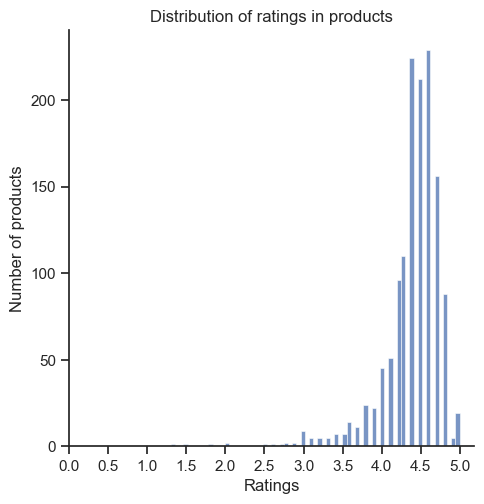

In [18]:
sns.set_theme(style='ticks')
sns.displot(df_search['rating'], kind='hist', fill=True)

ax = plt.gca()
plt.title('Distribution of ratings in products')
plt.xlabel('Ratings')
plt.xticks(np.arange(0, 5.5, 0.5))
plt.ylabel('Number of products')
plt.savefig('../visuals/4.2.b_histogram_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.3 Price

### 4.3a Prices with Discount

In [25]:
# count discount per category
df_discount_category = (
    df_search.groupby('category')['has_discount']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)
df_disc = df_discount_category.columns = ['category', 'no_discount', 'has_discount']
df_discount_category


,category,no_discount,has_discount
0,Beauty Personal Care,252,94
1,Electronics,161,145
2,Home Kitchen,188,172
3,Sports Outdoors,211,163


### 4.3a Price Discount Graphics

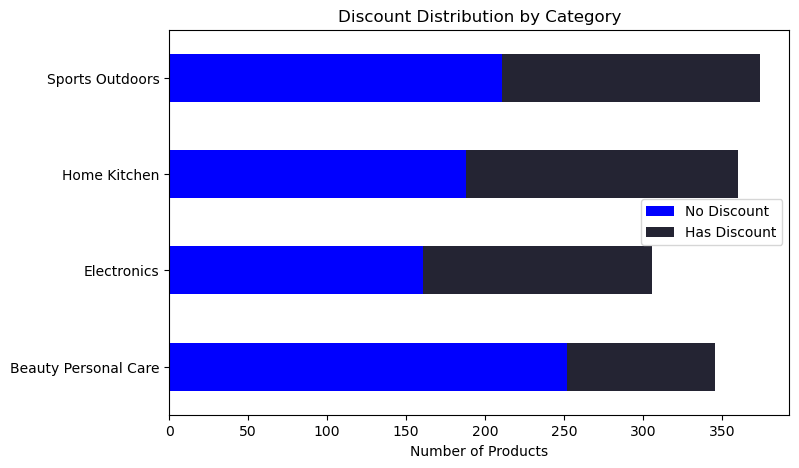

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

df_discount_category.plot(
    kind='barh',
    x='category',
    y=['no_discount', 'has_discount'],
    stacked=True,
    color=sns.color_palette('dark:b_r', 2),
    ax=ax
)

ax.set_title('Discount Distribution by Category')
ax.set_xlabel('Number of Products')
ax.set_ylabel('')
ax.legend(['No Discount', 'Has Discount'])
plt.savefig('../visuals/4.3.a_discount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3b Median Price by Category

In [21]:
# median price per category
df_median_price = (
    df_search.groupby('category')['price_primary']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)
df_median_price


,category,price_primary
0,Electronics,80.440
1,Sports Outdoors,19.985
2,Beauty Personal Care,14.990
3,Home Kitchen,13.990


### 4.3b Boxplot - Prices in Categorys 

C:\Users\moco\AppData\Local\Temp\ipykernel_17736\81353822.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


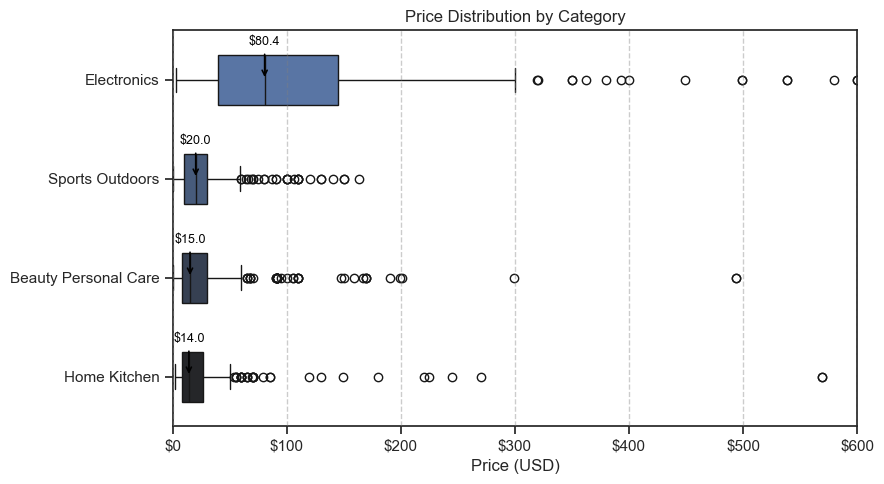

In [22]:
sns.set_theme(style='ticks')

fig, ax = plt.subplots(figsize=(9, 5))

# Boxplot as base
sns.boxplot(
    data=df_search,
    x='price_primary',
    y='category',
    order=df_median_price['category'],
    palette='dark:b_r',
    width=0.5,
    ax=ax
)

# Median annotations
medians = df_search.groupby('category')['price_primary'].median()
category_order = [tick.get_text() for tick in ax.get_yticklabels()]

for i, cat in enumerate(category_order):
    if cat in medians.index:
        median_val = medians[cat]
        ax.annotate(
            f'${median_val:.1f}',
            xy=(median_val, i),
            xytext=(median_val, i - 0.35),
            fontsize=9,
            color='black',
            ha='center',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2)
        )

# Grid and ticks
ax.xaxis.grid(True, linestyle='--', alpha=0.4, color='gray')
ax.set_axisbelow(False)
ax.set_xlim(0, 600)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x)}'))
ax.set_xlabel('Price (USD)')
ax.set_ylabel('')
ax.set_title('Price Distribution by Category')
plt.tight_layout()
plt.savefig('../visuals/4.3.b_boxplot_price_Distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.4 Sponsored

### 4.4 Donut Chart - % Sponsored 

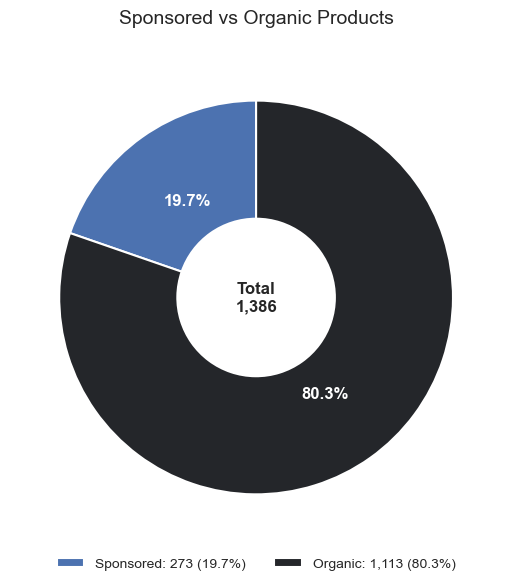

In [23]:
total     = len(df_search)
sponsored = df_search['sponsored'].sum()
organic   = total - sponsored

labels = ['Sponsored', 'Organic']
values = [sponsored, organic]
colors = sns.color_palette('dark:b_r', n_colors=2)

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    values,
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=12),
    startangle=90
)

# White text inside donut
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Total in center
ax.text(0, 0, f'Total\n{total:,}', ha='center', va='center', fontsize=12, fontweight='bold')

# Legend with % 
ax.legend(
    wedges,
    [f'{l}: {v:,} ({v/total*100:.1f}%)' for l, v in zip(labels, values)],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    fontsize=10,
    frameon=False
)

ax.set_title('Sponsored vs Organic Products', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../visuals/4.4._donut_sponsored_vs_organic.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Key Findings

- **Beauty & Personal Care dominates in sales volume**, representing ~60% of total estimated 
  sales across all categories, yet requires the fewest discounts to move products (only 27% 
  of its listings have a discount), suggesting strong organic demand.

- **Electronics punches above its weight in reviews**: despite representing only ~13% of 
  estimated sales, it generates a disproportionate share of reviews — likely driven by higher 
  price points that motivate buyers to leave feedback.

- **Most products sell in low volume tiers**: the majority of listings fall in the 50–100 
  sales/month range, with a secondary peak at 1K+, indicating that high-volume sellers are 
  the exception rather than the rule.

- **Ratings are consistently high across all categories**, clustering between 4.3–4.5, 
  which reflects Amazon's review ecosystem rather than meaningful quality differentiation 
  between categories.

- **Electronics has the widest price range** (median ~$80, up to $1K+) compared to other 
  categories which rarely exceed $250, making it an outlier in both price and review behavior.

- **80% of products rank organically** at the time of data collection, though this snapshot 
  reflects a single moment — Amazon's sponsored slots rotate continuously.